## Assignment: Image recognition
- Alumno 1: LAMY Léo
- Alumno 2: LACLAIS Melen
- Alumno 3: Adrián García-Pozuelo Fornieles

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile

url = 'https://drive.upm.es/s/2DDPE2zHw5dbM3G/download'
zip_name = 'dataset.zip'

r = requests.get(url, stream=True)
with open(zip_name, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024):
        f.write(chunk)

if os.path.getsize(zip_name) < 10000:
    print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
else:
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")

    target_file = 'xview_ann_train.json'
    found_path = None

    for root, dirs, files in os.walk("."):
        if target_file in files:
            found_path = os.path.join(root, target_file)
            break

    if found_path:
        print(f"SUCCÈS : Fichier trouvé à : {found_path}")

        import json
        json_file = found_path

        with open(json_file) as ifs:
            json_data = json.load(ifs)
        print("Base de données chargée avec succès !")

    else:
        print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_recognition/xview_ann_train.json
Base de données chargée avec succès !


In [2]:
import tensorflow as tf

# Vérifie la présence de processeurs graphiques
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configuration pour ne pas allouer toute la mémoire d'un coup
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU activé : {len(gpus)} processeur(s) détecté(s)")
    except RuntimeError as e:
        print(e)
else:
    print("GPU non détecté. Activez l'accélérateur dans les réglages du notebook.")

2026-03-07 03:11:12.946730: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772853073.138019      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772853073.195927      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772853073.664521      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772853073.664567      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772853073.664570      24 computation_placer.cc:177] computation placer alr

GPU activé : 1 processeur(s) détecté(s)


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [5]:
!pip install rasterio

In [6]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('./xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [7]:
import json

# Load database
json_file = './xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [8]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)
labels = [img.objects[0].category for img in anns]

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [ ]:
IMG_SIZE   = 224   
n_models   = 3

In [10]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.15, random_state=42, shuffle=True, stratify=labels)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 15934
Number of validation images: 2812


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Rescaling,
    GlobalAveragePooling2D, SpatialDropout2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.losses import CategoricalCrossentropy

BACKBONES = {
    'EfficientNetB0': tf.keras.applications.EfficientNetB0,
    'MobileNetV2':    tf.keras.applications.MobileNetV2,
    'ResNet50V2':     tf.keras.applications.ResNet50V2,
}

def create_transfer_model(backbone_name='EfficientNetB0',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3),
                           num_classes=13,
                           freeze_last_only=True,
                           label_smoothing=0.1,
                           lr=1e-3):

    BackboneClass = BACKBONES[backbone_name]
    img_input = Input(shape=input_shape, name='img_input')

    x = Rescaling(255.0)(img_input)

    backbone = BackboneClass(
        include_top=False, weights='imagenet',
        input_shape=input_shape, pooling=None
    )

    if freeze_last_only:
        backbone.trainable = False
        backbone.layers[-1].trainable = True   
    else:
        backbone.trainable = False            
    x = backbone(x, training=False)
    x = SpatialDropout2D(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=img_input, outputs=outputs)
    loss  = CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(optimizer=Nadam(lr), loss=loss, metrics=['accuracy'])
    return model

In [12]:
#from tensorflow.keras.optimizers import Adam
#
## Learning rate is changed to 0.001
#opt = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
#model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
#reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=10, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, early_stop, terminate]

In [14]:
import numpy as np
import tensorflow as tf

def mixup(images, labels, alpha=0.2):
    """MixUp data augmentation sur un batch numpy."""
    n    = len(images)
    lam  = np.random.beta(alpha, alpha, size=n).astype(np.float32)
    lam  = np.maximum(lam, 1 - lam)          # lam toujours ≥ 0.5
    perm = np.random.permutation(n)
    mixed_x = (lam[:, None, None, None] * images
                + (1 - lam[:, None, None, None]) * images[perm])
    mixed_y = lam[:, None] * labels + (1 - lam[:, None]) * labels[perm]
    return mixed_x.astype(np.float32), mixed_y.astype(np.float32)


def generator_images(objs, batch_size, do_shuffle=False,
                     do_mixup=False, class_weights=None):
    """
    Génère des batches (images [0,1], labels one-hot).
    - do_mixup   : MixUp en entraînement
    - class_weights : conservé pour compatibilité API (non utilisé,
                      label smoothing + MixUp couvrent le déséquilibre)
    """
    num_classes = len(categories)
    cat_list    = list(categories.values())

    while True:
        if do_shuffle:
            np.random.shuffle(objs)

        for start in range(0, len(objs), batch_size):
            group  = objs[start : start + batch_size]
            images, labels = [], []

            for filename, obj in group:
                img = load_geoimage(filename)
                t   = tf.image.convert_image_dtype(
                          tf.convert_to_tensor(img), tf.float32)
                t   = tf.image.resize(t, [IMG_SIZE, IMG_SIZE], method='bilinear')

                # Augmentation légère (active train + eval, sans effet néfaste)
                t = tf.image.random_flip_left_right(t)
                t = tf.image.random_flip_up_down(t)
                t = tf.image.random_brightness(t, max_delta=0.1)
                t = tf.clip_by_value(t, 0.0, 1.0)

                images.append(t.numpy())
                idx     = cat_list.index(obj.category)
                one_hot = tf.keras.utils.to_categorical(idx, num_classes)
                labels.append(one_hot)

            images = np.array(images, dtype=np.float32)
            labels = np.array(labels, dtype=np.float32)

            if do_mixup and len(images) > 1:
                images, labels = mixup(images, labels, alpha=0.2)

            yield images, labels

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

print('Calcul des poids de classes...')
y_train_indices = [list(categories.values()).index(obj.category) for _, obj in objs_train]
weights = compute_class_weight('balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weights = dict(enumerate(weights))

# Ajustements manuels (exemple)
class_weights[3] *= 1.5   # Truck
class_weights[9] *= 1.5   # Helipad

batch_size = 128

train_generator = generator_images(objs_train, batch_size, do_shuffle=True, class_weights=class_weights)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)


Calcul des poids de classes...


In [16]:
# ── GridSearch rapide : backbone × stratégie de gel ──────────────────
import math, gc

GS_EPOCHS = 5           # peu d'époques pour comparer rapidement
GS_FRAC   = 0.25        # fraction des données utilisée pendant la recherche

n_gs_train = max(batch_size * 4, int(len(objs_train) * GS_FRAC))
n_gs_valid = max(batch_size * 2, int(len(objs_valid) * GS_FRAC))
gs_objs_tr = objs_train[:n_gs_train]
gs_objs_va = objs_valid[:n_gs_valid]

# Grille : 3 backbones × 2 stratégies = 6 configs
grid = [
    ('EfficientNetB0', True),
    ('EfficientNetB0', False),
    ('MobileNetV2',    True),
    ('MobileNetV2',    False),
    ('ResNet50V2',     True),
    ('ResNet50V2',     False),
]

gs_results = {}
for bb_name, freeze_last in grid:
    config_key = f"{bb_name}|freeze={freeze_last}"
    print(f"\n▶ GridSearch — {config_key}")
    try:
        gs_tr_gen = generator_images(gs_objs_tr, batch_size, do_shuffle=True)
        gs_va_gen = generator_images(gs_objs_va, batch_size)
        gs_tr_steps = math.ceil(n_gs_train / batch_size)
        gs_va_steps = math.ceil(n_gs_valid / batch_size)

        m = create_transfer_model(
            backbone_name=bb_name,
            freeze_last_only=freeze_last,
            label_smoothing=0.1, lr=1e-3
        )
        hist = m.fit(
            gs_tr_gen, steps_per_epoch=gs_tr_steps,
            validation_data=gs_va_gen, validation_steps=gs_va_steps,
            epochs=GS_EPOCHS, verbose=0
        )
        best_val = max(hist.history['val_accuracy'])
        gs_results[config_key] = best_val
        print(f"   val_accuracy max = {best_val:.4f}")
        del m; gc.collect()
    except Exception as e:
        print(f"   ✗ Echec : {e}")
        gs_results[config_key] = 0.0

# Sélection de la meilleure config
best_key                        = max(gs_results, key=gs_results.get)
best_backbone, _freeze_str      = best_key.split('|freeze=')
best_freeze_last_only           = (_freeze_str == 'True')

print(f"\nMeilleure config : backbone={best_backbone}, "
      f"freeze_last_only={best_freeze_last_only}  "
      f"(val_acc={gs_results[best_key]:.4f})")
print("\nToutes les configs :")
for k, v in sorted(gs_results.items(), key=lambda x: -x[1]):
    print(f"  {k:45s}  →  {v:.4f}")


▶ GridSearch — EfficientNetB0|freeze=True


I0000 00:00:1772853104.051794      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


I0000 00:00:1772853152.705937      69 service.cc:152] XLA service 0x7f6ab8005ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772853152.706004      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772853158.518578      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-07 03:12:57.334616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:12:57.532911: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:12:58.214414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

   val_accuracy max = 0.6814

▶ GridSearch — EfficientNetB0|freeze=False
   val_accuracy max = 0.6629

▶ GridSearch — MobileNetV2|freeze=True
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


2026-03-07 03:21:33.167615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:21:33.370350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:22:28.331818: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:22:28.527646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   val_accuracy max = 0.2176

▶ GridSearch — MobileNetV2|freeze=False
   val_accuracy max = 0.4822

▶ GridSearch — ResNet50V2|freeze=True
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
   val_accuracy max = 0.3698

▶ GridSearch — ResNet50V2|freeze=False
   val_accuracy max = 0.1963

Meilleure config : backbone=EfficientNetB0, freeze_last_only=True  (val_acc=0.6814)

Toutes les configs :
  EfficientNetB0|freeze=True                     →  0.6814
  EfficientNetB0|freeze=False                    →  0.6629
  MobileNetV2|freeze=False                       →  0.4822
  ResNet50V2|freeze=True                         →  0.3698
  MobileNetV2|freeze=True                        →  0.2176
  ResNet50V2|freeze=False                        →  0.1963


In [17]:
train_size = len(objs_train)

# Générateurs finaux avec MixUp activé pour l'entraînement
train_generator = generator_images(objs_train, batch_size,
                                   do_shuffle=True, do_mixup=True)
valid_generator = generator_images(objs_valid, batch_size,
                                   do_shuffle=False, do_mixup=False)

models = []
for i in range(n_models):
    print(f"Création du modèle {i+1}/{n_models}  [{best_backbone}]")
    model = create_transfer_model(
        backbone_name=best_backbone,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=len(categories),
        freeze_last_only=best_freeze_last_only,
        label_smoothing=0.1,
        lr=1e-3
    )
    models.append(model)

Création du modèle 1/3  [EfficientNetB0]
Création du modèle 2/3  [EfficientNetB0]
Création du modèle 3/3  [EfficientNetB0]


In [18]:
import math
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

epochs      = 25
train_steps = math.ceil(len(objs_train) / batch_size)
valid_steps = math.ceil(len(objs_valid) / batch_size)

print('Entraînement des modèles')
for i, model in enumerate(models):
    print(f"\n--- Modèle {i+1}/{n_models} ---")

    ckpt = ModelCheckpoint(
        f'model_{i}.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
    early = EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    )

    model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        validation_data=valid_generator,
        validation_steps=valid_steps,
        epochs=epochs,
        callbacks=[ckpt, early, reduce_lr]
    )

Entraînement des modèles

--- Modèle 1/3 ---
Epoch 1/25
124/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5306 - loss: 1.7622

2026-03-07 03:40:48.483002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:40:48.675407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:40:49.227746: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:40:49.436870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:40:49.836781: E external/local_xla/xla/stream_

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5313 - loss: 1.7606
Epoch 1: val_accuracy improved from -inf to 0.63371, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.5320 - loss: 1.7591 - val_accuracy: 0.6337 - val_loss: 1.4496 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7127 - loss: 1.3575
Epoch 2: val_accuracy improved from 0.63371 to 0.71657, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.7127 - loss: 1.3576 - val_accuracy: 0.7166 - val_loss: 1.2388 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7430 - loss: 1.2915
Epoch 3: val_accuracy improved from 0.71657 to 0.77312, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.7430 - loss: 1.2914 - val_accuracy: 0.7731 - val_loss: 1.1189 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7766 - los

#### Validation
Compute validation metrics.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [20]:
import numpy as np
import tensorflow as tf

y_true, y_pred = [], []
all_images = []
temp_true_labels = []

print("Chargement des données de validation...")
for ann in anns_valid:
    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE], method='bilinear')

    for obj_pred in ann.objects:
        all_images.append(image_resized.numpy())
        temp_true_labels.append(obj_pred.category)

if all_images:
    X_valid = np.array(all_images)
    print(f"Lancement de la prédiction sur {len(X_valid)} objets...")

    # Moyenne des prédictions des 3 modèles
    all_predictions = np.mean([
        model.predict(X_valid, batch_size=128, verbose=1) for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i in range(len(all_predictions)):
        pred_category = category_names[np.argmax(all_predictions[i])]
        y_true.append(temp_true_labels[i])
        y_pred.append(pred_category)

Chargement des données de validation...
Lancement de la prédiction sur 2812 objets...
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 404ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 400ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step


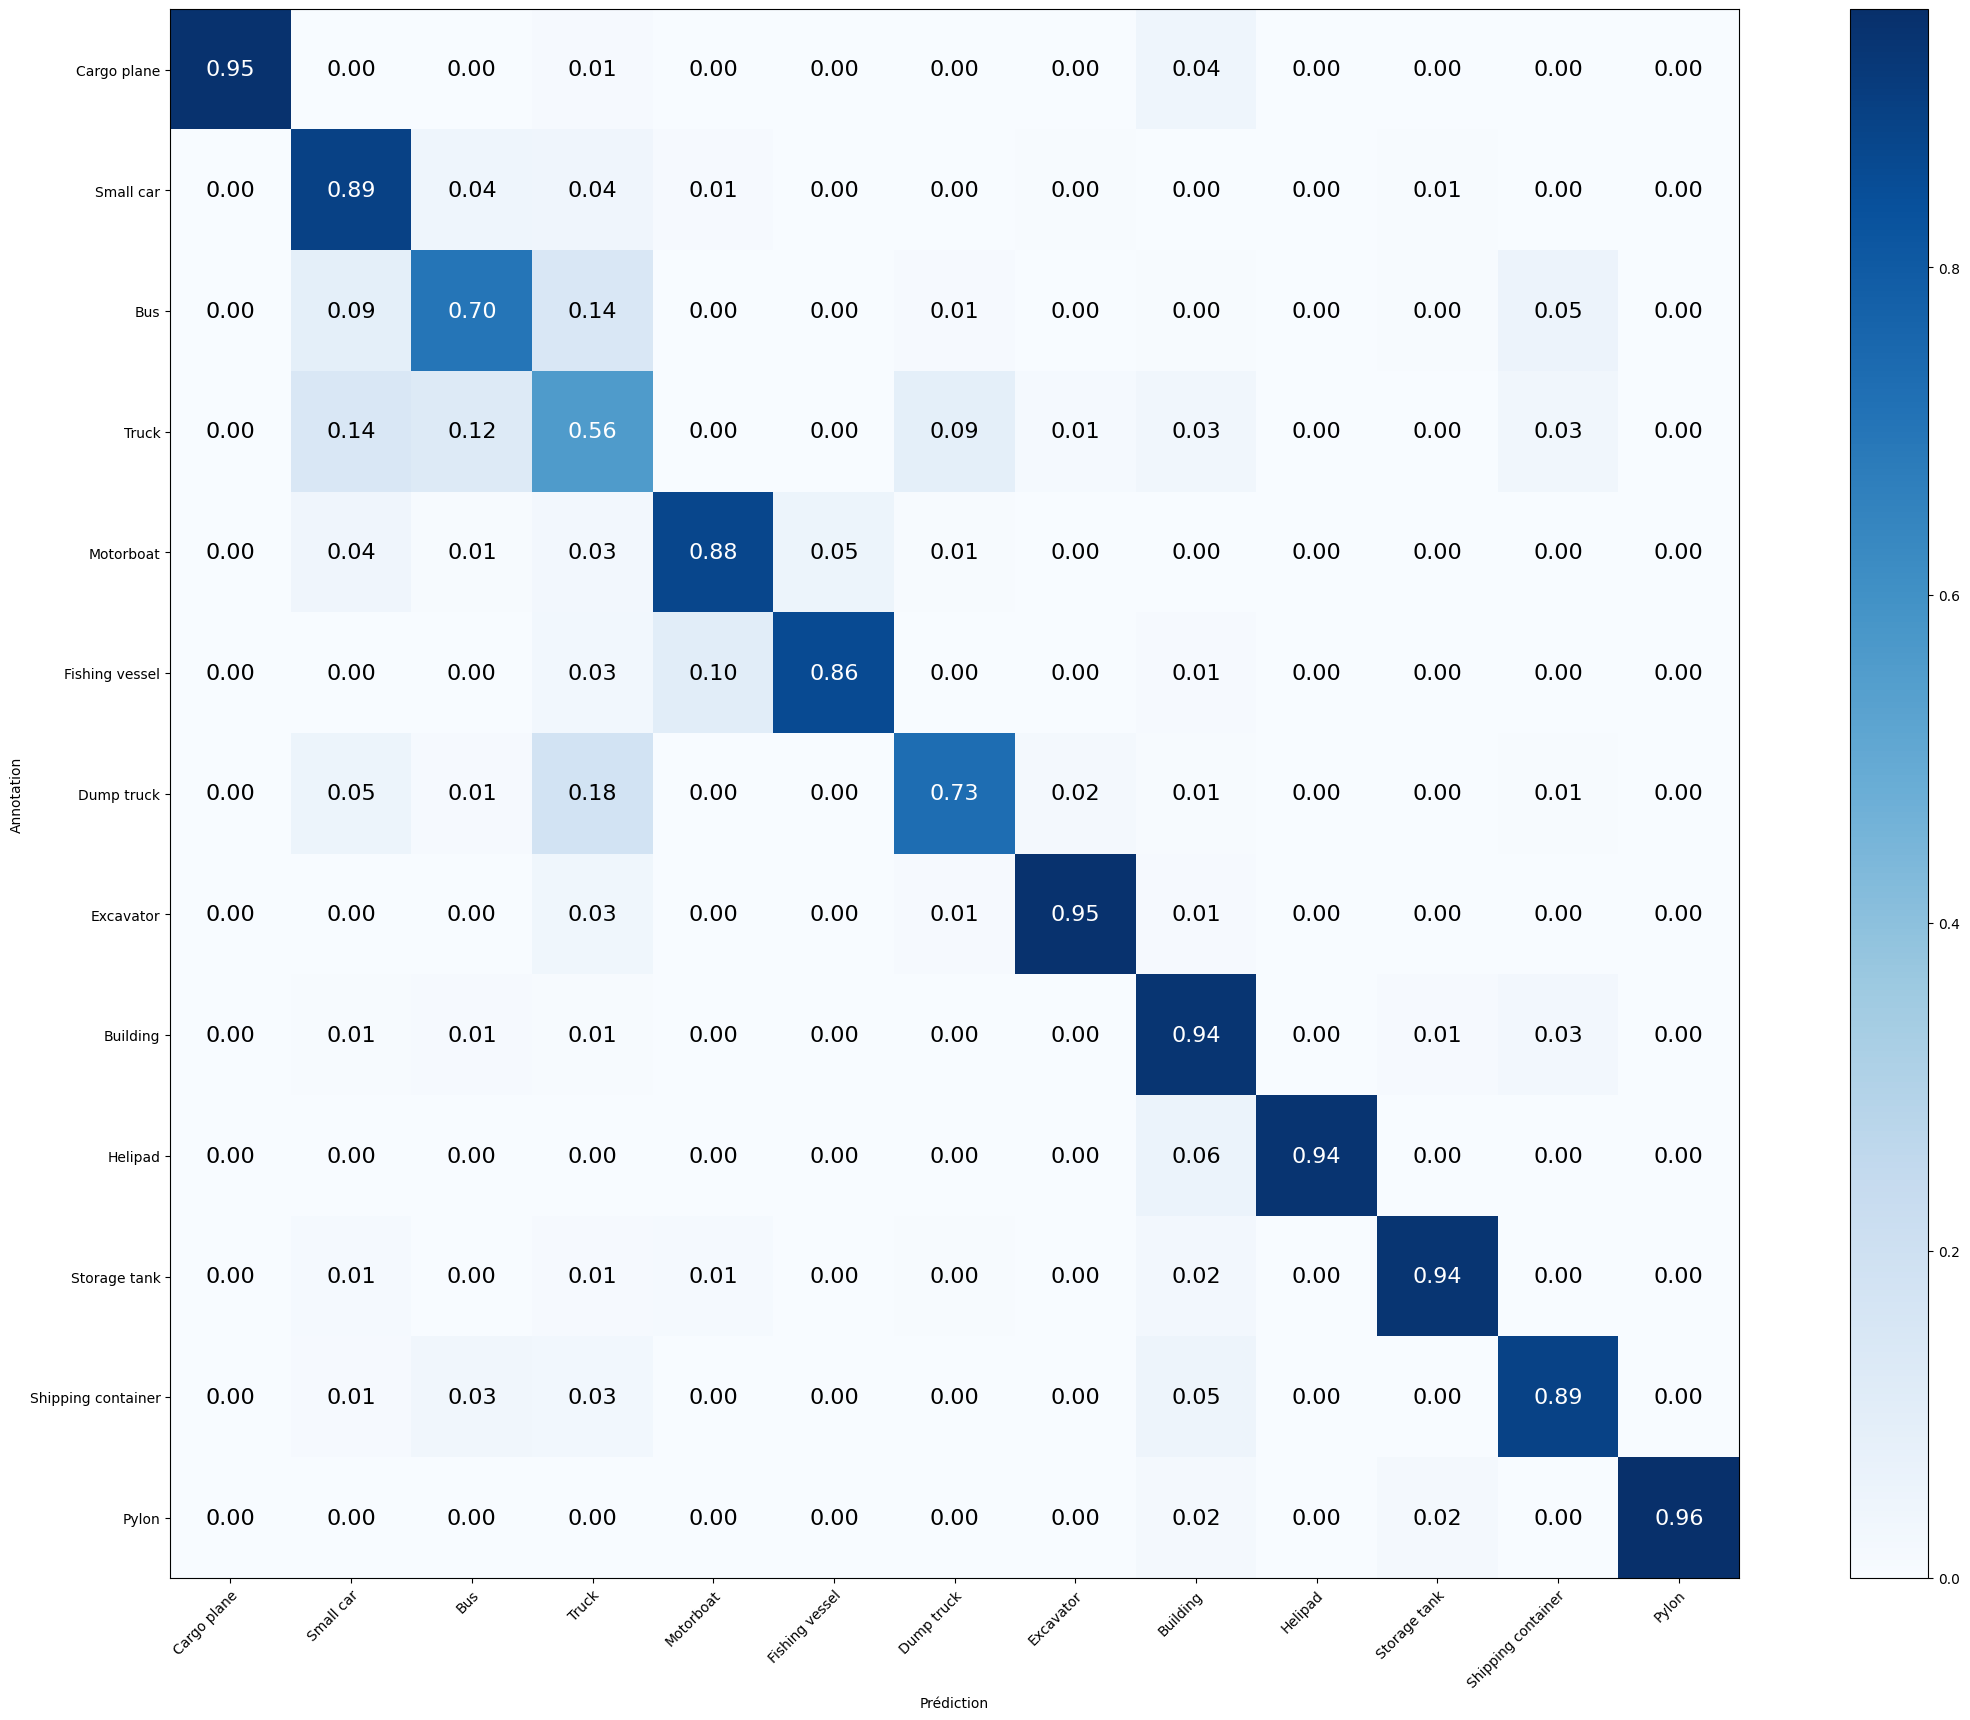

In [21]:
from sklearn.metrics import confusion_matrix

def draw_confusion_matrix(cm, categories):
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=list(categories.values()), yticklabels=list(categories.values()),
           ylabel='Annotation', xlabel='Prédiction')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm_norm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm_norm[i, j], '.2f'),
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

# Calcul et affichage
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [22]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 83.962%
Mean Recall: 85.954%
Mean Precision: 87.023%
> Cargo plane: Recall: 94.737% Precision: 100.000% Specificity: 100.000% Dice: 97.297%
> Small car: Recall: 89.379% Precision: 82.440% Specificity: 95.893% Dice: 85.769%
> Bus: Recall: 70.189% Precision: 70.722% Specificity: 96.977% Dice: 70.455%
> Truck: Recall: 56.024% Precision: 62.000% Specificity: 95.403% Dice: 58.861%
> Motorboat: Recall: 87.500% Precision: 88.050% Specificity: 99.284% Dice: 87.774%
> Fishing vessel: Recall: 85.849% Precision: 89.216% Specificity: 99.593% Dice: 87.500%
> Dump truck: Recall: 72.973% Precision: 79.412% Specificity: 98.668% Dice: 76.056%
> Excavator: Recall: 94.915% Precision: 91.803% Specificity: 99.629% Dice: 93.333%
> Building: Recall: 93.692% Precision: 93.002% Specificity: 98.328% Dice: 93.346%
> Helipad: Recall: 94.118% Precision: 100.000% Specificity: 100.000% Dice: 96.970%
> Storage tank: Recall: 93.636% Precision: 95.370% Specificity: 99.614% Dice: 94.495%
> Shipping contai

#### Testing
Try to improve the results provided in the competition.

In [23]:
import os
import numpy as np

anns = []
root_dir = './xview_recognition/'
test_dir = os.path.join(root_dir, 'xview_test')
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        rel_dir = os.path.relpath(dirpath, root_dir)
        clean_filename = os.path.join(rel_dir, filename)
        image = GenericImage(clean_filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = os.path.basename(dirpath)
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [24]:
import numpy as np
import tensorflow as tf

predictions_data = {"images": {}, "annotations": {}}
all_test_images = []
metadata = [] 
ann_id = 0

print("Préparation des images de test...")
for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img_final = image_resized.numpy()

    for obj_pred in ann.objects:
        all_test_images.append(img_final)
        metadata.append({
            "image_id": ann.filename.split('/')[-1],
            "bbox": [int(x) for x in obj_pred.bb]
        })

if all_test_images:
    X_test = np.array(all_test_images)
    print(f"Prédiction en cours sur {len(X_test)} détections...")
    # Moyenne des prédictions des 3 modèles
    all_preds = np.mean([
        model.predict(X_test, batch_size=128, verbose=1) for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i, pred in enumerate(all_preds):
        pred_category = category_names[np.argmax(pred)]
        predictions_data["annotations"][ann_id] = {
            "image_id": metadata[i]["image_id"],
            "category_id": pred_category,
            "bbox": metadata[i]["bbox"]
        }
        ann_id += 1

print("Test terminé.")

Préparation des images de test...
Prédiction en cours sur 2365 détections...
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 494ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 311ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step
Test terminé.


In [25]:
#for i, model in enumerate(models):
#    model.load_weights(f'model_{i}.keras')

In [26]:
import json
with open('prediction.json', 'w') as f:
    json.dump(predictions_data, f)